In [1]:
import numpy as np
import matplotlib.pyplot as plt

from load_eval import *

In [2]:
import seaborn as sns
custom_params = {"axes.spines.right": False, "axes.spines.top": False}
sns.set_theme(style="ticks", rc=custom_params)

import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 100
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

In [3]:
_= """Load eval_summary.md files into a structured representation for analysis.

Per dataset → per main qid ("1", "2", ...) → per sub-qid ("a", "b", ..., or "" if
the question has no sub-letter):

    data["sosa2024"]["1"]["a"] = {
        "title": "How are all the data ... loaded in?",
        "human":  [1, 1, 1, 1, 1, 1],          # length 6 (3 claude-code + 3 codex)
        "claude": [0, 1, 1, 1, 1, 1],
        "codex":  [1, 1, 1, 0, 0, 1],
        "best":   [None, None, None, None, None, None],   # or "Human" / "Claude judge"
        "agents": ["claude-code", "claude-code", "claude-code", "codex", "codex", "codex"],
        "trials": [1, 2, 3, 1, 2, 3],
        "overall": "...",                       # may be empty
    }

Rating scale: incorrect=-2, concerning=-1, ok=0, match=1, better=2; "—"/blank → None.
"""

In [4]:
data = load_all()
trials = list(iter_trials(data))

### Summary Analysis

In [ ]:
for dataset in data:
    eval = data[dataset]

### Additional Analysis

In [5]:
# agent performance comparsion
claude_scores = []
codex_scores = []

for dataset, qid, agent, trial, human, claude, codex, best_who, best_rating in trials:
    if agent == "claude-code":
        claude_scores.append(best_rating)

    elif agent == "codex":
        codex_scores.append(best_rating)

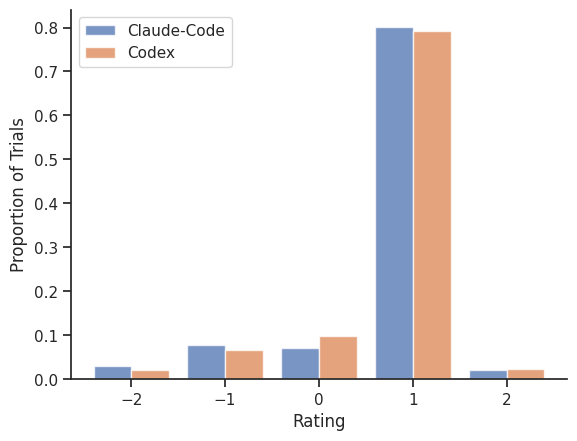

In [6]:
bins = np.arange(-2, 3)  # -2, -1, 0, 1, 2

claude_counts = np.array([sum(s == b for s in claude_scores if s is not None) for b in bins])
codex_counts  = np.array([sum(s == b for s in codex_scores  if s is not None) for b in bins])

claude_counts = claude_counts / sum(claude_counts)
codex_counts  = codex_counts  / sum(codex_counts)

width = 0.4
plt.bar(bins - width / 2, claude_counts, width, label="Claude-Code", color="C0", alpha=0.75)
plt.bar(bins + width / 2, codex_counts,  width, label="Codex",       color="C1", alpha=0.75)

plt.xticks(bins)
plt.xlabel("Rating")
plt.ylabel("Proportion of Trials")
plt.legend()
plt.show()

In [7]:
# trial variance analysis
questions = list(iter_questions(data))
all_diff = []
claude_diffs = []
codex_diffs = []

for q in questions:
    medium_rating = np.median(q['best_rating'])
    rating_diff = q['best_rating'] - medium_rating

    # append to all_diff
    all_diff.extend(rating_diff)

    # individual agent diff
    claude_rating = q['best_rating'][np.array(q['agents']) == "claude-code"]
    codex_rating  = q['best_rating'][np.array(q['agents']) == "codex"]

    claude_diff = claude_rating - np.median(claude_rating)
    codex_diff  = codex_rating  - np.median(codex_rating)
    claude_diffs.extend(claude_diff)
    codex_diffs.extend(codex_diff)

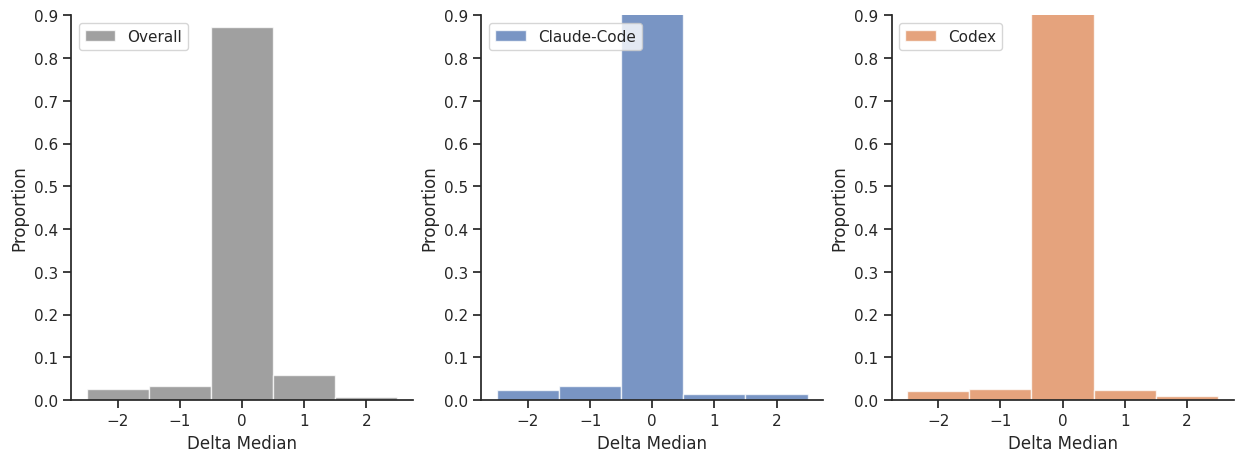

In [8]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
axs[0].hist(all_diff, bins=np.arange(-2.5, 3.5, 1), alpha=0.75, label="Overall", color="gray", density=True)
axs[1].hist(claude_diffs, bins=np.arange(-2.5, 3.5, 1), alpha=0.75, label="Claude-Code", color="C0", density=True)
axs[2].hist(codex_diffs,  bins=np.arange(-2.5, 3.5, 1), alpha=0.75, label="Codex", color="C1", density=True)

for ax in axs:
    ax.set_xlabel("Delta Median")
    ax.set_ylabel("Proportion")
    ax.set_ylim(0, 0.9)
    ax.legend(loc="upper left")

plt.show()

In [9]:
# trial variance analysis
questions = list(iter_questions(data))
all_diff = []
claude_diffs = []
codex_diffs = []

for q in questions:
    max_rating = np.max(q['best_rating'])
    rating_diff = q['best_rating'] - max_rating

    # append to all_diff
    all_diff.extend(rating_diff)

    # individual agent diff
    claude_rating = q['best_rating'][np.array(q['agents']) == "claude-code"]
    codex_rating  = q['best_rating'][np.array(q['agents']) == "codex"]

    claude_diff = claude_rating - np.max(claude_rating)
    codex_diff  = codex_rating  - np.max(codex_rating)
    claude_diffs.extend(claude_diff)
    codex_diffs.extend(codex_diff)

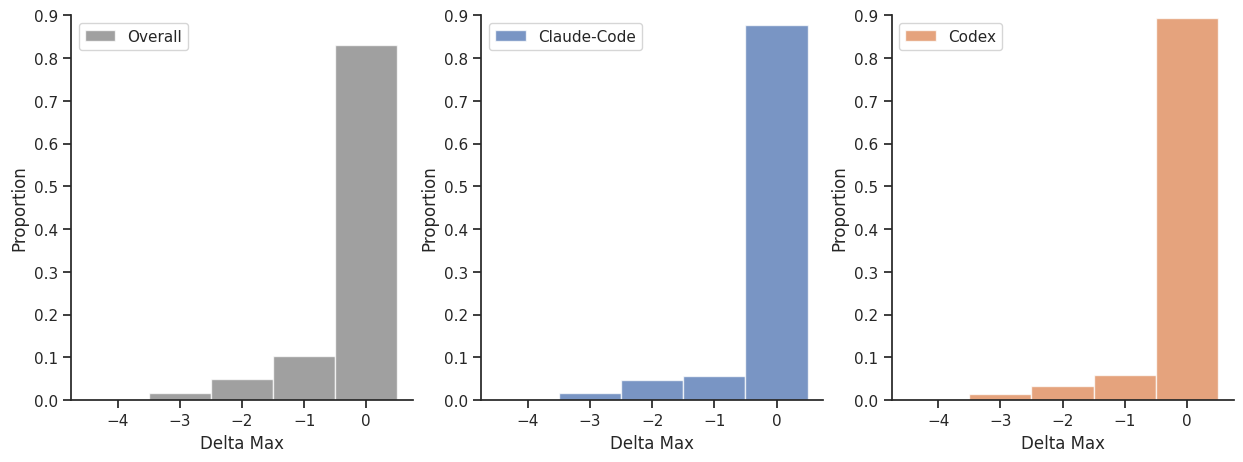

In [10]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
axs[0].hist(all_diff, bins=np.arange(-4.5, 1.5, 1), alpha=0.75, label="Overall", color="gray", density=True)
axs[1].hist(claude_diffs, bins=np.arange(-4.5, 1.5, 1), alpha=0.75, label="Claude-Code", color="C0", density=True)
axs[2].hist(codex_diffs,  bins=np.arange(-4.5, 1.5, 1), alpha=0.75, label="Codex", color="C1", density=True)

for ax in axs:
    ax.set_xlabel("Delta Max")
    ax.set_ylabel("Proportion")
    ax.set_ylim(0, 0.9)
    ax.legend()

plt.show()